In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas


Bearbetar 2019-01.jpg
Point 1: x=326, y=50
Point 2: x=559, y=124
Points: [(326, 50), (559, 124)]
Saved: ../SplitImages\2019-01_1.jpg
Point 1: x=295, y=146
Point 2: x=514, y=216
Points: [(295, 146), (514, 216)]
Saved: ../SplitImages\2019-01_2.jpg
Point 1: x=269, y=252
Point 2: x=495, y=343
Points: [(269, 252), (495, 343)]
Saved: ../SplitImages\2019-01_3.jpg
Point 1: x=230, y=362
Point 2: x=497, y=440
Points: [(230, 362), (497, 440)]
Saved: ../SplitImages\2019-01_4.jpg
Point 1: x=183, y=460
Point 2: x=440, y=560
Points: [(183, 460), (440, 560)]
Saved: ../SplitImages\2019-01_5.jpg

Bearbetar 2019-02.jpg
Point 1: x=258, y=38
Point 2: x=670, y=153
Points: [(258, 38), (670, 153)]
Saved: ../SplitImages\2019-02_1.jpg
Point 1: x=230, y=161
Point 2: x=550, y=235
Points: [(230, 161), (550, 235)]
Saved: ../SplitImages\2019-02_2.jpg
Point 1: x=162, y=279
Point 2: x=519, y=382
Points: [(162, 279), (519, 382)]
Saved: ../SplitImages\2019-02_3.jpg
Point 1: x=156, y=386
Point 2: x=542, y=508
Points: [(

ValueError: zero-size array to reduction operation minimum which has no identity

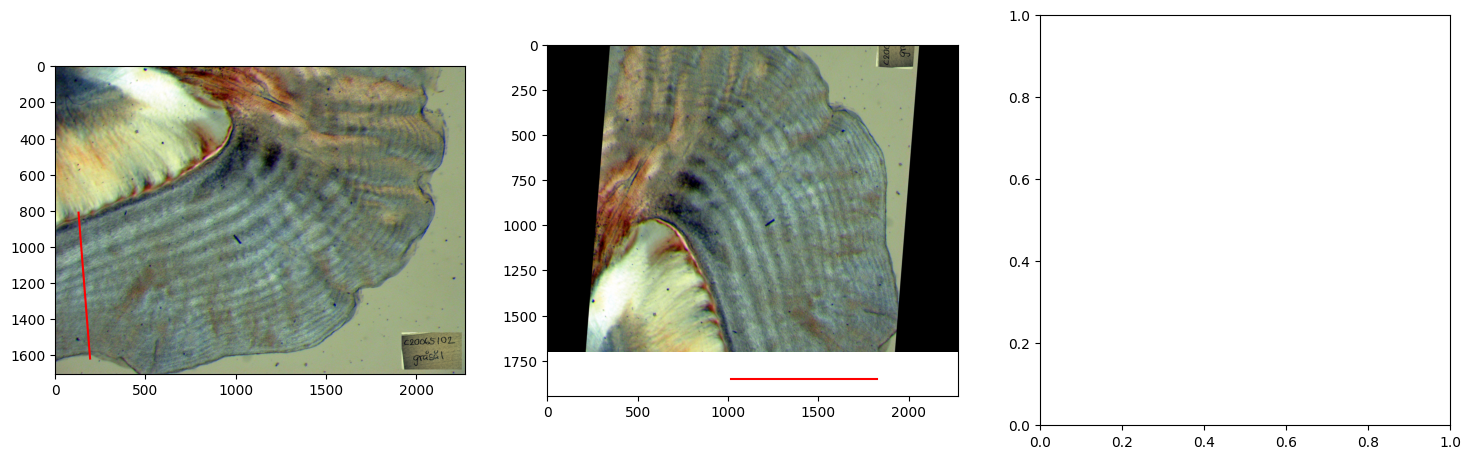

In [2]:
points = []

def get_points(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append((x, y))
        print(f"Point {len(points)}: x={x}, y={y}")

def rotate_point(x, y, M):
    x_new = M[0, 0]*x + M[0, 1]*y + M[0, 2]
    y_new = M[1, 0]*x + M[1, 1]*y + M[1, 2]
    return x_new, y_new

def create_samples(path, i):
    # points from clickcs
    I = cv2.imread(r'../images_original/' + path)
    I_h, I_w = I.shape[:2]
    I = cv2.cvtColor(I, cv2.COLOR_BGR2RGB)
    scale = 0.5
    I_small = cv2.resize(I, (int(I_w*scale), int(I_h*scale)))

    cv2.namedWindow("Click points", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Click points", 1000, 700) 
    cv2.imshow("Click points", I_small)      
    cv2.setMouseCallback("Click points", get_points)

    while True:
        cv2.waitKey(1)
        if len(points) >= 2:
            break

    cv2.destroyAllWindows()
    print(f'Points: {points}')
    x_1 = points[0][0] * 2
    x_2 = points[1][0] * 2
    y_1 = points[0][1] * 2
    y_2 = points[1][1] * 2
    dx = x_2 - x_1
    dy = y_2 - y_1
    angle_rad = np.arctan2(dy, dx)
    angle_deg = np.degrees(angle_rad)
    center = (I_w // 2, I_h // 2)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    rotated = cv2.warpAffine(I, M, (I_w, I_h))
    p1r = rotate_point(x_1, y_1, M)
    p2r = rotate_point(x_2, y_2, M)

    y_min = int(min(p1r[1], p2r[1]) - 100)
    y_max = int(max(p1r[1], p2r[1]) + 100)
    x_min = int(min(p1r[0], p2r[0]))
    x_max = int(max(p1r[0], p2r[0]))
    y_min = max(y_min, 0)
    y_max = min(y_max, I_h)
    x_min = max(x_min, 0)
    x_max = min(x_max, I_w)
    cropped = rotated[y_min:y_max, x_min:x_max]
    
    f, a = plt.subplots(1, 3, figsize=(18, 6))
    a = a.ravel()
    a[0].imshow(I)
    a[0].plot([x_1, x_2], [y_1, y_2], 'red')
    a[1].imshow(rotated)
    a[1].plot([p1r[0], p2r[0]], [p1r[1], p2r[1]], 'red')
    a[2].imshow(cropped)
    plt.close(f)

    os.makedirs('../SplitImages', exist_ok=True)
    base, ext = os.path.splitext(path)
    #Split images will end up SplitImages folder
    f_name = os.path.join('../SplitImages', f"{base}_{i+1}{ext}")
    cv2.imwrite(f_name, cropped)
    print(f"Saved: {f_name}")

#Folder of interest = SplitImages
for path in os.listdir('../images_original'):
    if path.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
        print(f"\nBearbetar {path}")
        for i in range(5):
            create_samples(path, i)
            points = []